# 🌸 Iris Classification using Support Vector Machine (SVM)

## Codveda Technologies - Machine Learning Internship

### Intern Information

**Name:** Muhammed Mumeenat

**Internship:** Machine Learning Internship

**Project:** Support Vector Machine (SVM) Classification

---

## Project Objective

The objective of this project is to develop a Support Vector Machine (SVM) classifier that predicts Iris flower species based on sepal and petal measurements.

The project demonstrates how SVM finds the optimal decision boundary that separates different flower species while maximizing the margin between classes.

# 1. Importing Required Libraries

The required Python libraries are imported for data manipulation, model training, visualization, and performance evaluation.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score

)

# 2. Loading the Dataset

The Iris dataset is loaded into a Pandas DataFrame. Each row represents a flower sample, while each column represents one of its measurements.

In [7]:
df = pd.read_csv("../datasets/iris.csv")

df.head ()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 3. Exploring the Dataset

The dataset is explored to understand its dimensions, data types, and to check for missing values before model training.

In [8]:
df.shape

(150, 5)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [10]:
df.describe

<bound method NDFrame.describe of      sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]>

In [11]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# 4. Encoding the Target Variable

The target variable (**species**) contains text labels.

Label Encoding converts each flower species into a numerical value so that the Support Vector Machine can process the data.

In [12]:
encoder = LabelEncoder()

df["species"] = encoder.fit_transform(df["species"])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# 5. Feature Selection

The dataset is divided into input features (X) and the target variable (y).

The input features contain the flower measurements, while the target variable contains the encoded flower species.

In [13]:
X = df.drop("species", axis=1)

y = df["species"]

print(X.shape)
print(y.shape)

(150, 4)
(150,)


# 6. Splitting the Dataset

The dataset is divided into training and testing sets.

The training set is used to train the Support Vector Machine model, while the testing set is used to evaluate its performance on unseen data.

In [15]:
X_train, X_test, y_train, y_test = train_test_split (
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


# 7. Feature Scaling

Support Vector Machines are sensitive to the scale of input features.

StandardScaler is applied to ensure that all features have a similar scale, improving the model's performance and stability.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 8. Training the Support Vector Machine

A Support Vector Machine classifier is trained using the scaled training dataset.

The model learns the optimal decision boundary that separates the Iris flower species.

In [18]:
model = SVC(kernel="linear", random_state=42)
model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


# 9. Making Predictions

The trained Support Vector Machine model is used to predict the species of Iris flowers in the testing dataset.

In [19]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# 10. Model Accuracy

Accuracy measures the percentage of correctly classified flower samples in the testing dataset.

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print ("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


# 11. Confusion Matrix

The confusion matrix compares the actual flower species with the species predicted by the Support Vector Machine model.

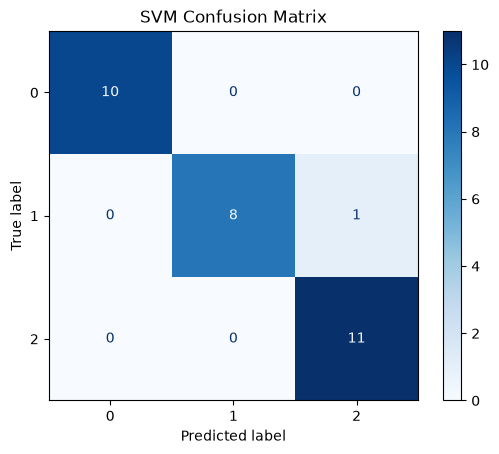

In [21]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("SVM Confusion Matrix")

plt.show()

# 12. Classification Report

The classification report summarizes the model's performance using Precision, Recall, F1-Score, and Support for each Iris flower species.

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



# 13. F1-Score

The F1-Score combines Precision and Recall into a single evaluation metric.

A higher F1-Score indicates better classification performance.

In [23]:
f1 = f1_score(y_test, y_pred, average="weighted")

print("F1 Score:", f1)

F1 Score: 0.9664109121909632


# 14. Conclusion

A Support Vector Machine (SVM) classifier was successfully developed to classify Iris flower species based on their measurements.

The dataset was explored, preprocessed, and scaled using StandardScaler before training the model. The trained SVM classifier was evaluated using standard classification metrics.

The final model achieved:

- Accuracy: 96.67%
- F1-Score: 96.64%

The confusion matrix showed that only one Versicolor flower was incorrectly classified as Virginica, while all other flower samples were correctly predicted.

This project demonstrates the effectiveness of Support Vector Machines in solving classification problems by identifying the optimal decision boundary between different classes.